In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from pyproj import Transformer, CRS

In [2]:
h2_path = '../00_raw_data/hydrogen_abundance/hydrogenhd.txt'

h2_raw = pd.read_csv(
    h2_path, comment='#', header=None,
    names=['lat_min', 'lat_max', 'lon_min', 'lon_max', 'h_ppm'],
    sep=',', skipinitialspace=True
)

h2_raw['h_ppm'] = pd.to_numeric(
    h2_raw['h_ppm'].astype(str).str.strip(), errors='coerce'
)
h2_raw['reliable'] = h2_raw['h_ppm'] >= 0

# ref: Feldman et al. (2001), JGR, doi:10.1029/2000JE001408
print(f"Total bins:     {len(h2_raw):,}")
print(f"Reliable bins:  {h2_raw['reliable'].sum():,}")
print(f"H ppm range:    {h2_raw['h_ppm'].min():.1f} to {h2_raw['h_ppm'].max():.1f}")

C:\Users\Aska\AppData\Local\Temp\ipykernel_13376\1884335340.py:3: DtypeWarning: Columns (0: h_ppm) have mixed types. Specify dtype option on import or set low_memory=False.
  h2_raw = pd.read_csv(


Total bins:     259,200
Reliable bins:  255,019
H ppm range:    -56.2 to 195.6


In [3]:
# resample the 0.5-degree hydrogen bins onto each site's slope grid,
# fine enough to resolve variation within a 2km-radius EZ near the
# south pole, where 0.5deg longitude corresponds to only 1-2km

sites_df = pd.read_csv('../01_cleaned_data/sites_df.csv')

moon_gcs = CRS.from_proj4('+proj=longlat +R=1737400 +no_defs')
moon_spole = CRS.from_proj4(
    '+proj=stere +lat_0=-90 +lon_0=0 +k=1 '
    '+x_0=0 +y_0=0 +R=1737400 +units=m +no_defs'
)
to_latlon = Transformer.from_crs(moon_spole, moon_gcs, always_xy=True)

lat_lookup = {}
for _, r in h2_raw.iterrows():
    lat_key = int(np.floor((r['lat_min'] + 90) / 0.5))
    lon_key = int(np.floor((r['lon_min'] if r['lon_min'] >= 0
                            else r['lon_min'] + 360) / 0.5))
    lat_lookup[(lat_key, lon_key)] = r['h_ppm']

for _, row in sites_df.iterrows():
    site_key  = row['site_key']
    grid_file = f'../01_cleaned_data/site_grids/{site_key}_grids.pkl'

    with open(grid_file, 'rb') as f:
        g = pickle.load(f)

    h, w = g['slope'].shape

    rows_idx, cols_idx = np.meshgrid(np.arange(h), np.arange(w), indexing='ij')
    x_coords = g['transform'].c + cols_idx * g['transform'].a
    y_coords = g['transform'].f + rows_idx * g['transform'].e

    lons_grid, lats_grid = to_latlon.transform(x_coords.ravel(), y_coords.ravel())
    lats_grid = lats_grid.reshape(h, w)
    lons_grid = lons_grid.reshape(h, w)

    lat_bin_idx = np.floor((lats_grid + 90) / 0.5).astype(int)
    lon_norm    = np.where(lons_grid < 0, lons_grid + 360, lons_grid)
    lon_bin_idx = np.floor(lon_norm / 0.5).astype(int)

    flat_vals = np.array([
        lat_lookup.get((la, lo), np.nan)
        for la, lo in zip(lat_bin_idx.ravel(), lon_bin_idx.ravel())
    ])
    h2_ppm_grid = flat_vals.reshape(h, w)

    g['h2_ppm_grid'] = h2_ppm_grid

    with open(grid_file, 'wb') as f:
        pickle.dump(g, f)

    valid_pct = round(np.mean(~np.isnan(h2_ppm_grid)) * 100, 1)
    print(f"{row['Site']:25s}  H2 grid: {h2_ppm_grid.shape}  "
          f"coverage: {valid_pct}%  "
          f"range: {np.nanmin(h2_ppm_grid):.1f}-{np.nanmax(h2_ppm_grid):.1f} ppm")

print("\nHydrogen grids saved.")

Nobile Rim 2               H2 grid: (602, 602)  coverage: 100.0%  range: 88.9-114.6 ppm
Mons Mouton                H2 grid: (502, 502)  coverage: 100.0%  range: 126.8-151.9 ppm
Malapert Massif            H2 grid: (626, 626)  coverage: 100.0%  range: 122.2-143.0 ppm
de Gerlache Rim 2          H2 grid: (600, 600)  coverage: 100.0%  range: 130.6-145.6 ppm
Mons Mouton Plateau        H2 grid: (2018, 2018)  coverage: 100.0%  range: 59.6-154.6 ppm
Slater Plain               H2 grid: (600, 600)  coverage: 100.0%  range: 119.1-145.2 ppm
Peak near Cabeus B         H2 grid: (600, 600)  coverage: 100.0%  range: 131.7-155.5 ppm
Nobile Rim 1               H2 grid: (600, 600)  coverage: 100.0%  range: 142.0-154.6 ppm
Haworth                    H2 grid: (846, 846)  coverage: 100.0%  range: 127.0-143.5 ppm

Hydrogen grids saved.


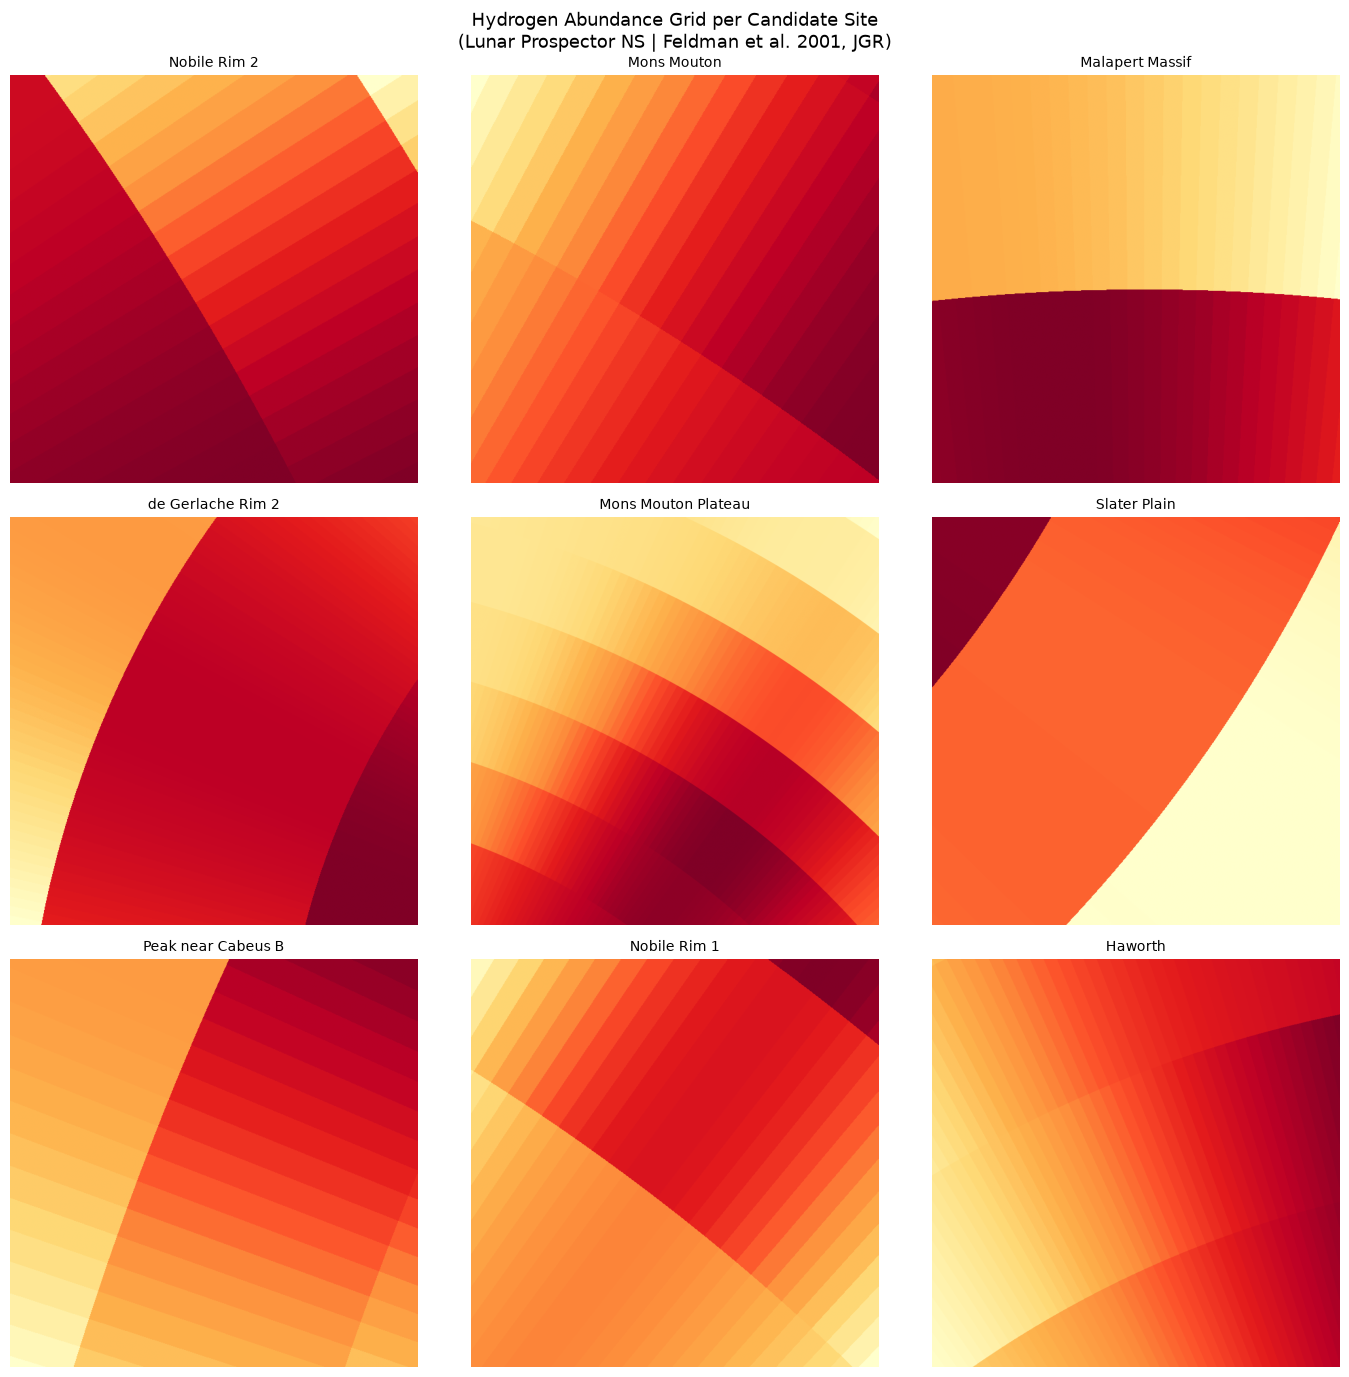

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(14, 14))

for ax, (_, row) in zip(axes.flat, sites_df.iterrows()):
    site_key  = row['site_key']
    grid_file = f'../01_cleaned_data/site_grids/{site_key}_grids.pkl'
    with open(grid_file, 'rb') as f:
        g = pickle.load(f)

    ax.imshow(g['h2_ppm_grid'], cmap='YlOrRd')
    ax.set_title(row['Site'], fontsize=10)
    ax.axis('off')

plt.suptitle('Hydrogen Abundance Grid per Candidate Site\n'
             '(Lunar Prospector NS | Feldman et al. 2001, JGR)', fontsize=13)
plt.tight_layout()
plt.show()